In [1]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import numpy as np
import matplotlib.pyplot as plt

import os.path as osp

import torch
from lightning.pytorch import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from src.datasets import DatasetBuilder
from src.models.classifiers import SimpleCNNtorch, build_resnet50
from src.models.lightning_wrappers import ClassifierLightningWrapper 
from src.utils import seed_everything, get_config, load_model_weights, evaluate_classification_model

2026-03-27 17:56:51.320979: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 17:56:51.334579: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774630611.350367 1501188 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774630611.355143 1501188 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774630611.367395 1501188 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [6]:
seed_everything()
plt.style.use('seaborn-v0_8-darkgrid')

# Pytorch model

In [42]:
# config_path = r"D:\PycharmProjects\CF-Robustness-Benchmark\configs\train_classifier_derma.yaml"
config_path = r'/data/leuven/365/vsc36567/CF-Robustness-Benchmark/configs/train_classifier_derma.yaml'
config = get_config(config_path)

In [58]:
ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

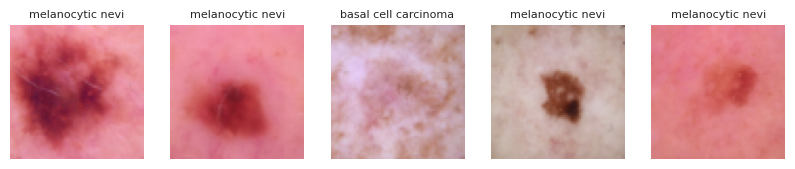

In [59]:
n_samples = 5
class_names = ds_builder.class_encodings
fig, axs = plt.subplots(1, n_samples, figsize=(10, 6))

batch = next(iter(train_loader))
images = batch[0][:n_samples]
labels = batch[1][:n_samples]

for i in range(n_samples):
    axs[i].imshow(images[i, ...].permute(1, 2, 0))
    axs[i].set_title(class_names[labels[i].item()], fontdict={'fontsize': 8})
    axs[i].axis("off")

In [60]:
def setup_model(config):
    cnn = None
    if config.classifier.name == "SimpleCNNTorch":
        cnn = SimpleCNNtorch(**config.classifier.args,
                             num_classes=config.data.num_classes, 
                             img_size=config.data.img_size)
    elif config.classifier.name == "resnet50":
        cnn = build_resnet50(config.data.num_classes)

    optimizer_cls = getattr(torch.optim, config.optimizer.name)
    optimizer = optimizer_cls(cnn.parameters(), **config.optimizer.args)

    loss = getattr(torch.nn, config.loss.name)(**config.loss.args)
    
    if config.lr_scheduler.enable:
        lr_scheduler_cls = getattr(torch.optim.lr_scheduler, config.lr_scheduler.name)
        lr_scheduler = lr_scheduler_cls(optimizer, **config.lr_scheduler.args)
        

    return cnn, optimizer, loss, lr_scheduler


In [75]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm
from torchmetrics import Accuracy
import copy


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2025)
dataset = ds_builder.train_dataset
labels = dataset.data.labels.ravel()
batch_size = config.batch_size
device = config.accelerator
epochs = 20
results = {}
save_dir = osp.join(config.save_dir, 'multiclass/cv')
config.optimizer.args['lr'] = 1e-3
config.optimizer.args['weight_decay'] = 0

# Split the dataset into 5 folds
for fold, (train_idx, val_idx) in enumerate(kfold.split(dataset, labels)):
    print(f"Fold {fold}:")

    # Create subsets for training and validation
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)

    fold_train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    fold_val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    model, optimizer, loss, lr_scheduler = setup_model(config)
    model = model.to(device)
    best_val_loss = float('inf')
    epochs_no_improve = 0
    patience = 3  # epochs number before early stopping

    for epoch in range(epochs):
        # Training phase
        model.train()
        for batch in fold_train_loader:
            inputs, targets = batch[0].to(device), batch[1].to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            train_loss = loss(outputs, targets)

            train_loss.backward()
            optimizer.step()

        lr_scheduler.step(train_loss)
        print('learning_rate', lr_scheduler.get_last_lr())

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_accuracy = 0.0
        val_metric = Accuracy(task="binary" if config.data.num_classes == 2 else "multiclass",
                              num_classes=config.data.num_classes).to(device)

        with torch.no_grad():
            for batch in fold_val_loader:
                inputs, targets = batch[0].to(device), batch[1].to(device)
                outputs = model(inputs)
                val_loss += loss(outputs, targets).item()
                val_accuracy += val_metric(torch.argmax(outputs, axis=1), targets).item()

        val_loss /= len(fold_val_loader)
        val_accuracy /= len(fold_val_loader)
        print("Epoch {}/{}, val_loss: {:.4f}, val_accuracy: {:.4f}".format(epoch + 1, epochs,
                                                                           val_loss, val_accuracy))

        # Early stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    # Save results for this fold
    results[fold] = best_val_loss
    torch.save(best_model_wts, osp.join(save_dir, f'model_fold_{fold}.pth'))

print(f"Cross-validation results: {results}")

Fold 0:
learning_rate [0.001]
Epoch 1/20, val_loss: 0.5268, val_accuracy: 0.8043
learning_rate [0.001]
Epoch 2/20, val_loss: 0.5174, val_accuracy: 0.8028
learning_rate [0.001]
Epoch 3/20, val_loss: 0.5962, val_accuracy: 0.7909
learning_rate [0.001]
Epoch 4/20, val_loss: 0.6761, val_accuracy: 0.7634
learning_rate [0.001]
Epoch 5/20, val_loss: 0.6320, val_accuracy: 0.7500
Early stopping at epoch 5
Fold 1:
learning_rate [0.001]
Epoch 1/20, val_loss: 0.5228, val_accuracy: 0.8095
learning_rate [0.001]
Epoch 2/20, val_loss: 0.5270, val_accuracy: 0.7790
learning_rate [0.001]
Epoch 3/20, val_loss: 0.6903, val_accuracy: 0.7374
learning_rate [0.001]
Epoch 4/20, val_loss: 0.7205, val_accuracy: 0.7597
Early stopping at epoch 4
Fold 2:
learning_rate [0.001]
Epoch 1/20, val_loss: 0.5969, val_accuracy: 0.7626
learning_rate [0.001]
Epoch 2/20, val_loss: 0.5288, val_accuracy: 0.7946
learning_rate [0.001]
Epoch 3/20, val_loss: 0.5670, val_accuracy: 0.8140
learning_rate [0.001]
Epoch 4/20, val_loss: 0.51

In [71]:
weights_path = osp.join(config.save_dir, 'multiclass/cv/model_fold_3.pth')
model, _, _, _ = setup_model(config)
model.load_state_dict(torch.load(weights_path))
model.eval()

evaluate_classification_model(model.to('cpu'), test_loader, num_classes=4)


Accuracy for the test dataset: 81.139%


In [74]:
classes, class_counts = np.unique(train_loader.dataset.data.labels, return_counts=True)
total_num = train_loader.dataset.data.labels.shape[0]
num_classes = len(class_counts)
raw_weights = torch.Tensor([num_classes * (1 - count/total_num).item() for count in class_counts])
class_weights = raw_weights / raw_weights.sum()

cnn, optimizer, _, lr_scheduler = setup_model(config) 
# cnn, optimizer, loss, lr_scheduler = setup_model(config) 
loss = getattr(torch.nn, config.loss.name)(class_weights.to(config.accelerator))

# config.accelerator = 'cpu'
cnn = cnn.to(config.accelerator)

AttributeError: 'Subset' object has no attribute 'data'

In [73]:
from tqdm import tqdm 
import copy

training_info = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
best_model_wts = copy.deepcopy(cnn.state_dict())

for epoch in tqdm(range(config.epochs), desc="Training of the clasifier on DermaMNIST dataset", total=config.epochs):
    
    cnn.train()
    train_loss = 0.0

    for batch in tqdm(train_loader, desc="Training", total=len(train_loader), leave=False):
        images, labels = batch
        images = images.to(config.accelerator)
        labels = labels.to(config.accelerator)

        optimizer.zero_grad()
        logits = cnn(images)

        loss_value = loss(logits, labels)
        train_loss += loss_value.item()
        loss_value.backward()
    
        optimizer.step()
    
    train_loss = train_loss / len(train_loader)
    training_info['train_loss'].append(train_loss)
    print("Epoch: {} | Train loss: {:.4f}".format(epoch, train_loss))
    
    with torch.no_grad():
        cnn.eval()
        val_loss = 0.0
        for batch in val_loader:
            images, labels = batch
            images = images.to(config.accelerator)
            labels = labels.to(config.accelerator)

            logits = cnn(images)
            loss_value = loss(logits, labels)
            val_loss += loss_value.item()

        val_loss = val_loss / len(val_loader)
        training_info['val_loss'].append(val_loss)
        print("Epoch: {} | Val loss: {:.4f}".format(epoch, val_loss))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(cnn.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

cnn.load_state_dict(best_model_wts)

Training of the clasifier on DermaMNIST dataset:   0%|          | 0/30 [00:00<?, ?it/s]


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [63]:
evaluate_classification_model(cnn.to('cpu'), test_loader, num_classes=4)

Accuracy for the test dataset: 76.842%


In [32]:
torch.save(cnn.state_dict(), osp.join(config.save_dir, 'binary/checkpoints/derma_epoch=30_accuracy=0.83_resnet50.pth'))

In [33]:
weights_path = r'/data/leuven/365/vsc36567/CF-Robustness-Benchmark/notebooks/experiments/derma_classification/binary/checkpoints/derma_epoch=30_accuracy=0.83_resnet50.pth'
load_model_weights(cnn, weights_path=weights_path)

In [34]:
cnn.eval()
cnn.to('cpu')
evaluate_classification_model(cnn, test_loader, num_classes=2)

Accuracy for the test dataset: 82.986%


# Tensorflow model

In [ ]:
import os
import sys
import keras
import tensorflow as tf

from tensorflow.keras.utils import to_categorical 
from tensorflow.keras import Sequential
from keras.layers import Input
from keras.models import Model
from tensorflow.keras.applications import ResNet50
from keras.layers import Dense, GlobalAveragePooling2D

In [3]:
seed_everything()

repo_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark'
config_path = osp.join(repo_dir, r"configs\train_classifier_derma.yaml")
# '/data/leuven/365/vsc36567/CF-Robustness-Benchmark/configs/train_classifier_derma.yaml'
config = get_config(config_path)
config.data_dir = osp.join(repo_dir, config.data_dir)
config.data.channels_first = False

In [4]:
ds_builder = DatasetBuilder(config)
ds_builder.setup()

In [ ]:
# class ArrayLoader:
#     def __init__(self, images, labels, input_size=64, input_channels=3):
#         # DataLoader.__init__(self)
#         self.images = images
#         self.labels = labels
#         self.input_size = input_size
#         self.input_channels = input_channels

#     def load_images_and_labels(self, imgs_names, do_center_crop=False):
#         # img_names is the indices of images/labels to be returned
#         imgs = self.images[imgs_names]
#         labels = self.labels[imgs_names]
#         # TODO : check correctnes of the command
#         imgs = np.resize(imgs, (imgs.shape[0], self.input_size, self.input_size, self.input_channels))
#         imgs = imgs / 255.0

#         return imgs, labels
    
# train_loader = ArrayLoader(ds_builder.train_dataset.data.imgs, ds_builder.train_dataset.data.labels,
#                           input_size=224, input_channels=3)
# test_loader = ArrayLoader(ds_builder.test_dataset.data.imgs, ds_builder.test_dataset.data.labels,
#                           input_size=224, input_channels=3)

In [ ]:
train_images = ds_builder.train_dataset.data.imgs / 255.0

train_labels = to_categorical(ds_builder.train_dataset.data.labels)

val_images = ds_builder.val_dataset.data.imgs / 255.0
val_labels = to_categorical(ds_builder.val_dataset.data.labels)

test_images = ds_builder.test_dataset.data.imgs / 255.0
test_labels = to_categorical(ds_builder.test_dataset.data.labels)

In [195]:
train_images_comb = np.concatenate([train_images, val_images], axis=0)
train_labels_comb = np.concatenate([train_labels, val_labels], axis=0)

In [196]:
batch_size = config.batch_size

train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).shuffle(train_labels.shape[0]).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels)).shuffle(val_labels.shape[0]).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(batch_size)

In [157]:
images, labels = train_ds.as_numpy_iterator().next()

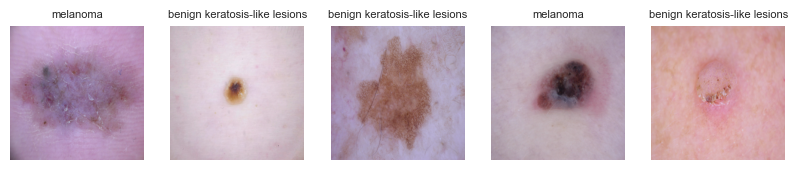

In [122]:
plt.style.use('seaborn-v0_8-darkgrid')

n_samples = 5
class_names = ds_builder.class_encodings
fig, axs = plt.subplots(1, n_samples, figsize=(10, 6))

for i in range(n_samples):
    axs[i].imshow(images[i, ...])
    axs[i].set_title(class_names[labels[i].item()], fontdict={'fontsize': 8})
    axs[i].axis("off")

In [230]:
# preprocessing = tf.keras.layers.Rescaling(scale=1./255)
preprocessing = tf.keras.applications.resnet50.preprocess_input


input_tensor = Input(shape=(224, 224, 3))
x = preprocessing(input_tensor)
x = ResNet50(weights='imagenet', include_top=False)(x)
x = GlobalAveragePooling2D()(x)
# let's add a fully-connected layer
output = Dense(config.data.num_classes, activation='sigmoid')(x)

# this is the model we will train
model = Model(inputs=input_tensor, outputs=output)

In [231]:
optimizer = tf.keras.optimizers.Adam(learning_rate=config.optimizer.args['lr'])
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
train_label_sizes = np.unique(train_labels_comb, return_counts=True)[1]
total_train_size = train_label_sizes.sum() 
class_weights = {i: 1 - count/total_train_size for i, count in enumerate(train_label_sizes)}

# class NormalizationCheckCallback(keras.callbacks.Callback):
#     def on_batch_begin(self, batch, logs=None):
#         batch_ind = batch
#         train_images_comb = train_images_comb[batch_ind: batch_ind + batch_size]
#         print("Mean and variance of the batch: ", train_images_comb.mean())

early_stopping_callbacks = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.1,
    patience=3,
    verbose=0,
    mode='auto'
)

# norm_check_callback = NormalizationCheckCallback()

In [233]:
model.fit(x=train_images_comb, y=train_labels_comb, validation_split=0.2, 
        batch_size=batch_size, callbacks=[early_stopping_callbacks], shuffle=True,
        class_weight=class_weights, epochs=10, verbose=1)

Epoch 1/10
51/51 [==============================] - 321s 6s/step - loss: 0.2917 - accuracy: 0.7274 - val_loss: 0.3821 - val_accuracy: 0.8775
Epoch 2/10
51/51 [==============================] - 719s 14s/step - loss: 0.2288 - accuracy: 0.7827 - val_loss: 0.3855 - val_accuracy: 0.8775
Epoch 3/10
51/51 [==============================] - 1045s 20s/step - loss: 0.1760 - accuracy: 0.8459 - val_loss: 0.3987 - val_accuracy: 0.8775


In [234]:
accuracy = 0
for batch in test_ds:
    images, labels = batch
    predictions = model.predict(images)
    # print(predictions, labels)
    accuracy += np.sum(np.argmax(predictions, axis=1) == tf.argmax(labels, axis=1).numpy()) / batch_size
print("Test accuracy: {:.4f}".format(accuracy / 5))

1/1 [==============================] - 2s 2s/step
Test accuracy: 0.4375


In [173]:
model.save(r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\derma_classification\binary\checkpoints\resnet50_derma_acc65.keras')

In [ ]:
def train(model, config, data_train, data_test, output_dir=None):

    # ============= Experiment Folder=============
    if not output_dir:
        try:
            output_dir = osp.join(config['log_dir'], config['name'])
            os.makedirs(output_dir)
        except Exception as e:
            print("Error creating output directory: ", e)
            
    
    # ============= Experiment Parameters =============
    BATCH_SIZE = config.batch_size
    EPOCHS = config.epochs
    channels = config.classifier.args.input_channels
    input_size = config.data.img_size
    N_CLASSES = config.data.num_classes
    ckpt_dir_continue = config.classifier.checkpoints_path
    
    if ckpt_dir_continue == '':
        continue_train = False
    else:
        continue_train = True


    # ============= placeholder =============
    with tf.name_scope('input'):
        x_ = tf.compat.v1.placeholder(tf.float32, [None, input_size, input_size, channels], name='x-input')
        y_ = tf.compat.v1.placeholder(tf.int64, [None, N_CLASSES], name='y-input')
        isTrain = tf.compat.v1.placeholder(tf.bool)
    # ============= Model =============
    y = y_
    logits = model(x)
    predictions = tf.argmax(logits, axis=-1)
    classif_loss = tf.losses.binary_crossentropy(y_true=y, y_pred=predictions, from_logits=False)
    classif_acc = calc_accuracy(prediction=predictions, labels=y)
    loss = tf.losses.get_total_loss()

    # ============= Optimization functions =============    
    train_step = tf.train.AdamOptimizer(0.0001).minimize(loss)
    
    # ============= summary =============    
    cls_loss = tf.summary.scalar('classif_loss', classif_loss)
    total_loss = tf.summary.scalar('total_loss', loss)
    cls_acc = tf.summary.scalar('classif_acc', classif_acc)
    sum_train = tf.summary.merge([cls_loss, total_loss, cls_acc])
    
    # ============= Variables =============
    # Note that this list of variables only include the weights and biases in the model.
    lst_vars = []
    for v in tf.global_variables():
        lst_vars.append(v)
    
    # ============= Session =============
    sess = tf.InteractiveSession()
    saver = tf.train.Saver(var_list=lst_vars)
    tf.global_variables_initializer().run()
    writer = tf.summary.FileWriter(output_dir + '/train', sess.graph)
    
    # ============= Checkpoints =============
    if continue_train:
        print("Before training, Load checkpoint ")
        print("Reading checkpoint...")
        ckpt = tf.train.get_checkpoint_state(ckpt_dir_continue)
        if ckpt and ckpt.model_checkpoint_path:
            ckpt_name = osp.basename(ckpt.model_checkpoint_path)
            saver.restore(sess, osp.join(ckpt_dir_continue, ckpt_name))
            print(ckpt_name)
            print("Successful checkpoint upload")
        else:
            print("Failed checkpoint load")
            sys.exit()
    
    # ============= Training =============
    train_loss = []
    itr_train = 0
    
    for epoch in range(EPOCHS):
        total_loss = 0.0
        num_batches = int(data_train.shape[0] / BATCH_SIZE)

        for i in range(0, num_batches):
            start_ind = i * BATCH_SIZE
            ns = data_train[start_ind:start_ind + BATCH_SIZE]
            xs, ys = train_loader.load_images_and_labels(ns, do_center_crop=True)
            [_, _loss, summary_str] = sess.run([train_step, loss, sum_train], feed_dict={x_: xs, isTrain: True, y_: ys})
            writer.add_summary(summary_str, itr_train)
            itr_train += 1
            total_loss += _loss
        total_loss /= i
        print("Epoch: " + str(epoch) + " loss: " + str(total_loss) + '\n')
        train_loss.append(total_loss)

        
        checkpoint_name = osp.join(output_dir, 'checkpoints_epoch' + str(epoch) + '.ckpt')
        saver.save(sess, checkpoint_name)


In [14]:
train(model, config, train_loader, test_loader, output_dir=osp.join(repo_dir, 'notebooks\experiments\derma_classification\binary\checkpoints'))

RuntimeError: tf.placeholder() is not compatible with eager execution.